# True Parameters at 1 PA Model

```python

m1 = 1e6
m2 = 1e4
a = -0.9 # 0.95
p0 = 42.0
e0 = 5.00000000e-01
xI0 = 1.0
dist = 5.0
qS = 1.04719755e+00
phiS = 7.85398163e-01
qK = 6.28318531e-01

phiK = 5.23598776e-01
Phi_phi0 = 0.1
Phi_theta0 =0.2
Phi_r0 = 0.3

dt = 10.0
T = 1.0

chi2 = 9.50000000e-01

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True

best_fit = [ 1.38200811e+01,6.33238062e+03,-8.96151413e-01,4.21591531e+01,4.99958263e-01,1.76591062e+00,1.08140575e+00,1.55045250e-01,3.95573277e-01,-2.28156450e-01,-1.62510561e-03]

# logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = [ 1.38200811e+01,6.33238062e+03,-8.96151413e-01,4.21591531e+01,4.99958263e-01,
            1.76591062e+00,1.08140575e+00,1.55045250e-01,3.95573277e-01,-2.28156450e-01,-1.62510561e-03]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 5.0
qS = best_fit[5]
phiS = best_fit[6]
qK = 6.28318531e-01 
phiK =  5.23598776e-01
Phi_phi0 = best_fit[7]
Phi_theta0 = 0.2
Phi_r0 = best_fit[8]

dt = 10.0
T = 1.0

chi2 = 9.50000000e-01

dev_0_p=best_fit[9]
dev_0_e=best_fit[10]
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [4]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1004581.0028941679), 6332.38062, -0.896151413, 42.1591531, 0.499958263, 1.0, 5.0, 1.76591062, 1.08140575, 0.628318531, 0.523598776, 0.15504525, 0.2, 0.395573277, 0.95, False, False, False, True, -0.22815645, -0.00162510561, 0.0, 0.0, 0.0, 0.0)
SNR:  4.11352272217017


Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1004581.0028941679), 6332.38062, -0.896151413, 42.1591531, 0.499958263, 1.0, 5.0, 1.76591062, 1.08140575, 0.628318531, 0.523598776, 0.15504525, 0.2, 0.395573277, 0.95, False, False, False, True, -0.22815645, -0.00162510561, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 4.11352272217017
The optimal source SNR is <= 20. The Fisher approximation may not be valid!
calculating stable deltas...
Gamma_ii for m1: 0.0991917407623854
Gamma_ii for m1: 0.09919173962255529
Gamma_ii for m1: 0.09919173907208538
Gamma_ii for m1: 0.09919173678736659
Gamma_ii for m1: 0.09919174039653839
Gamma_ii for m1: 0.09919172363177843
Gamma_ii for m1: 0.09919173309371614
Gamma_ii for m1: 0.09919174044861909
Gamma_ii for m1: 0.09919174051725013
Gamma_ii for m1: 0.09919174213745643
Gamma_ii for m1: 0.09919174070332722
Gamma_ii for m1: 0.09919139999676997
Gamma_ii for m1: 0.0991915685637502

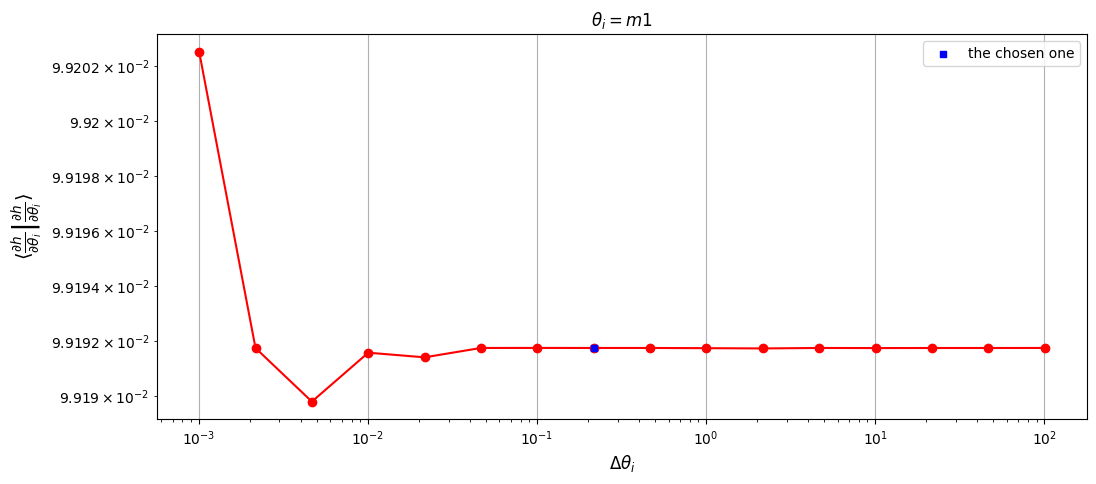

Gamma_ii for m2: 37.56510412555641
Gamma_ii for m2: 37.565105325937566
Gamma_ii for m2: 37.56510533037082
Gamma_ii for m2: 37.565093266841416
Gamma_ii for m2: 37.56513106483184
Gamma_ii for m2: 37.56510509740506
Gamma_ii for m2: 37.565105324267016
Gamma_ii for m2: 37.5650927699619
Gamma_ii for m2: 37.5652448495416
Gamma_ii for m2: 37.565105427027156
Gamma_ii for m2: 37.564582090868925
Gamma_ii for m2: 37.56510848836171
Gamma_ii for m2: 37.58005995017225
Gamma_ii for m2: 37.53278999292678
Gamma_ii for m2: 37.49815218098902
Gamma_ii for m2: 37.56508950801673
[np.float64(3.1954686292956545e-08), np.float64(1.1801520919753649e-10), np.float64(3.2113668181702935e-07), np.float64(1.0061988166015636e-06), np.float64(6.912645848370071e-07), np.float64(6.0391673287613486e-09), np.float64(3.3420136061863154e-07), np.float64(4.048411778182793e-06), np.float64(3.7114900346707e-06), np.float64(1.3931637971250402e-05), np.float64(1.4012936843969352e-05), np.float64(0.0003978562522349419), np.float64

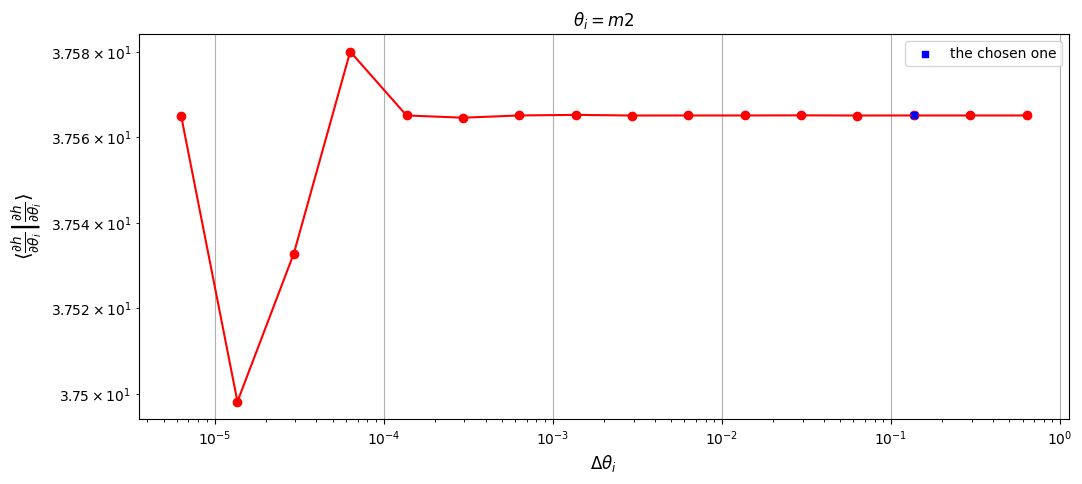

Gamma_ii for a: 2632929.193244112
Gamma_ii for a: 2633019.431401172
Gamma_ii for a: 2632828.3881202056
Gamma_ii for a: 2632764.5258412077
Gamma_ii for a: 2632560.3806877895
Gamma_ii for a: 2629562.0634787395
Gamma_ii for a: 2623691.039340802
Gamma_ii for a: 2617270.4931724886
Gamma_ii for a: 2701069.4675778397
Gamma_ii for a: 2606674.2727427455
Gamma_ii for a: 2817427.7572432244
Gamma_ii for a: 3189103.5114431307
Gamma_ii for a: 2321558.097955204
Gamma_ii for a: 1250185.6421626979
Gamma_ii for a: 1822859.1137270243
Gamma_ii for a: 12174528.703363886
[np.float64(3.427173988305005e-05), np.float64(7.256199524002457e-05), np.float64(2.4256737878026956e-05), np.float64(7.754623784349737e-05), np.float64(0.0011402344332133696), np.float64(0.002237696455072145), np.float64(0.002453145819303829), np.float64(0.031024368462650866), np.float64(0.03621288467920909), np.float64(0.07480350967603706), np.float64(0.1165455285055065), np.float64(0.37369101994563414), np.float64(0.8569706927197929), np

/home/svu/e1583490/scratch/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


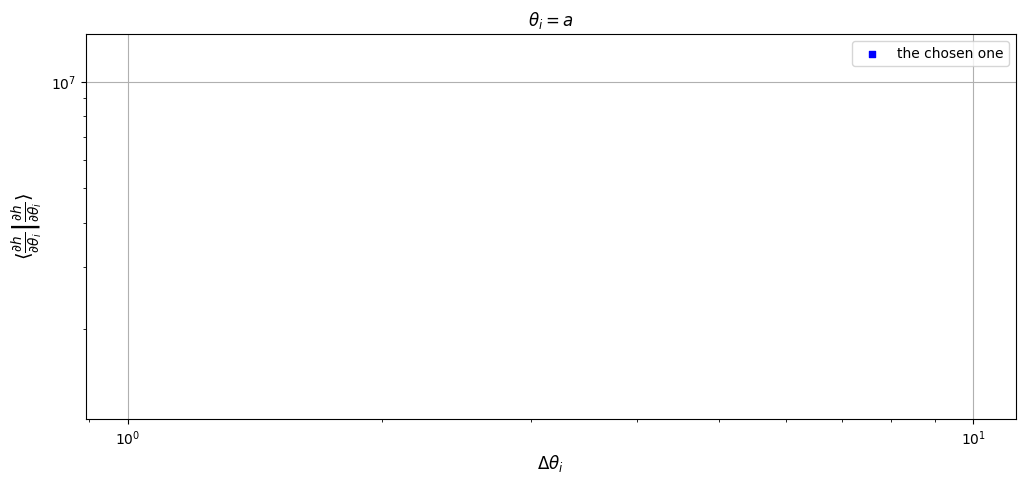

Gamma_ii for p0: 148481598.66073608
Gamma_ii for p0: 148481599.2839446
Gamma_ii for p0: 148481603.28629908
Gamma_ii for p0: 148481600.4676982
Gamma_ii for p0: 148481600.92409983
Gamma_ii for p0: 148481634.5959258
Gamma_ii for p0: 148481572.58075058
Gamma_ii for p0: 148481602.42848772
Gamma_ii for p0: 148481838.8561115
Gamma_ii for p0: 148481744.6144856
Gamma_ii for p0: 148483275.55037433
Gamma_ii for p0: 148480389.508395
Gamma_ii for p0: 148483447.8985252
Gamma_ii for p0: 148485920.4141822
Gamma_ii for p0: 148493296.7069557
Gamma_ii for p0: 148496836.67848805
[np.float64(4.197210467842925e-09), np.float64(2.695522128191423e-08), np.float64(1.898282941551273e-08), np.float64(3.073792599869252e-09), np.float64(2.2677434867156018e-07), np.float64(4.176624354488436e-07), np.float64(2.01019767064262e-07), np.float64(1.5922999445588446e-06), np.float64(6.347017685556134e-07), np.float64(1.0310493778257578e-05), np.float64(1.9437192944456304e-05), np.float64(2.0597515571647908e-05), np.float6

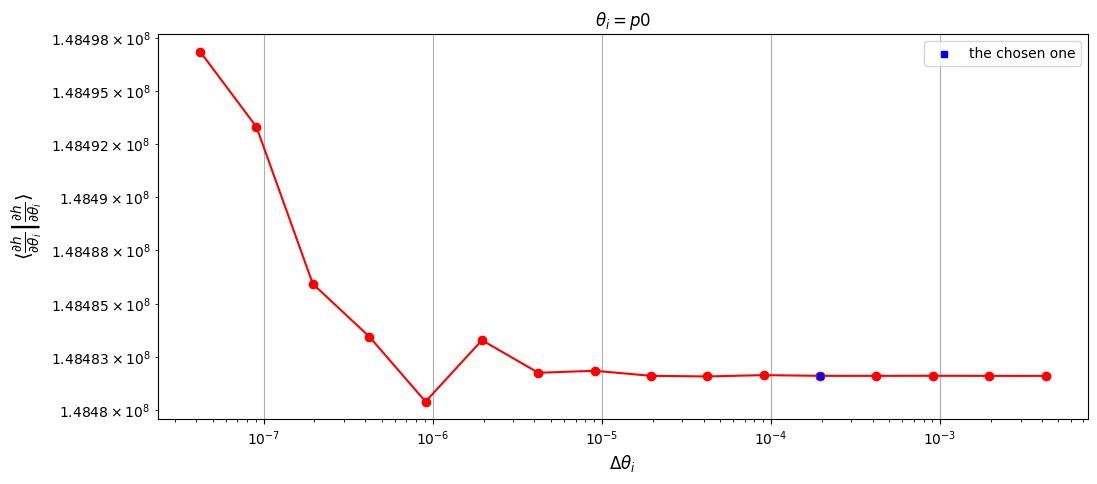

Gamma_ii for e0: 164748216235.7754
Gamma_ii for e0: 164748214204.30615
Gamma_ii for e0: 164748215591.08282
Gamma_ii for e0: 164748202548.29428
Gamma_ii for e0: 164748203654.72736
Gamma_ii for e0: 164748123811.29822
Gamma_ii for e0: 164748045278.08194
Gamma_ii for e0: 164748390275.69962
Gamma_ii for e0: 164749173724.68478
Gamma_ii for e0: 164747343482.32132
Gamma_ii for e0: 164749518695.8607
Gamma_ii for e0: 164751683272.43735
Gamma_ii for e0: 164755105533.95245
Gamma_ii for e0: 164727818819.56253
Gamma_ii for e0: 164724216308.65344
Gamma_ii for e0: 164505254365.6354
[np.float64(1.233075118958195e-08), np.float64(8.41755200435896e-09), np.float64(7.916801726487917e-08), np.float64(6.715903727059688e-09), np.float64(4.846393833876731e-07), np.float64(4.766867864533275e-07), np.float64(2.09408794282264e-06), np.float64(4.755404640011684e-06), np.float64(1.1109389230672207e-05), np.float64(1.3203155654635171e-05), np.float64(1.3138418580408435e-05), np.float64(2.0771808582289715e-05), np.f

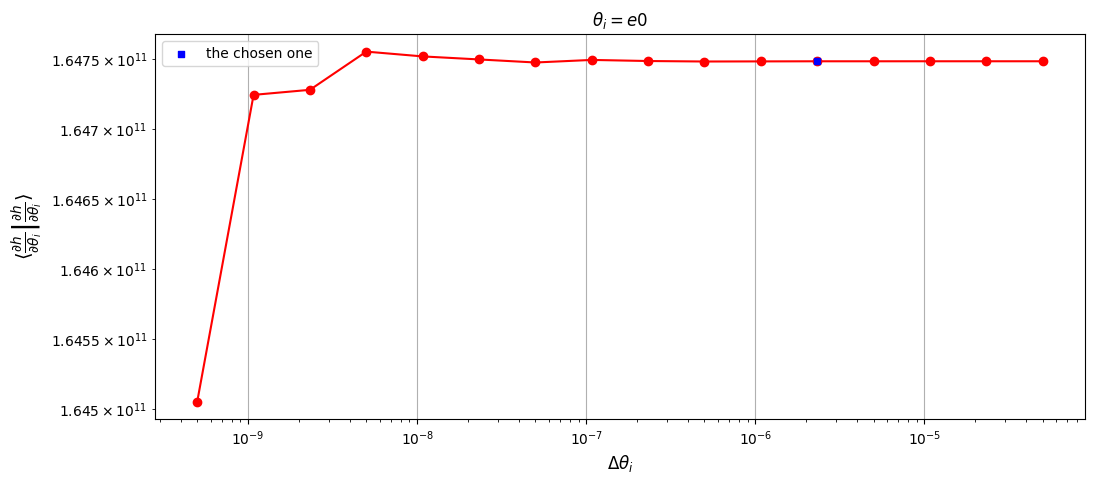

Gamma_ii for qS: 38.35077372472076
Gamma_ii for qS: 38.35077483196029
Gamma_ii for qS: 38.35077483305619
Gamma_ii for qS: 38.350774833057535
Gamma_ii for qS: 38.350774833056086
Gamma_ii for qS: 38.350774833052995
Gamma_ii for qS: 38.350774833061834
Gamma_ii for qS: 38.35077483304024
Gamma_ii for qS: 38.35077483308499
Gamma_ii for qS: 38.35077483310113
Gamma_ii for qS: 38.35077483306582
Gamma_ii for qS: 38.35077483325471
Gamma_ii for qS: 38.35077483317374
Gamma_ii for qS: 38.35077483443882
Gamma_ii for qS: 38.35077483090236
Gamma_ii for qS: 38.35077483250491
[np.float64(2.8871373044834444e-08), np.float64(2.857583955657089e-11), np.float64(3.501691364600583e-14), np.float64(3.7796033776642644e-14), np.float64(8.059448378843566e-14), np.float64(2.304816961673353e-13), np.float64(5.630497384669826e-13), np.float64(1.1668599055152743e-12), np.float64(4.207587877777188e-13), np.float64(9.206298619416157e-13), np.float64(4.925341970162079e-12), np.float64(2.111390200574991e-12), np.float64(3

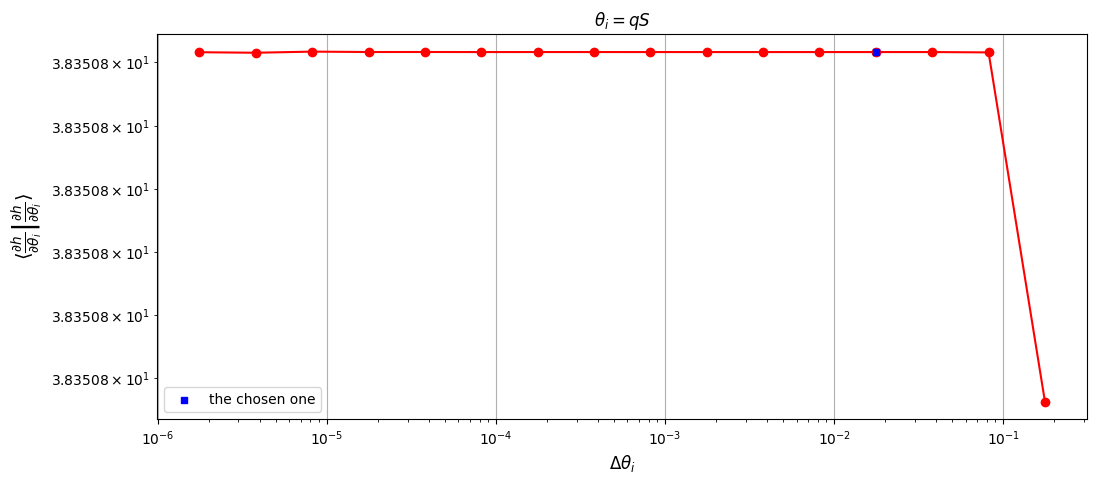

Gamma_ii for phiS: 22.479090585362883
Gamma_ii for phiS: 22.479090592115455
Gamma_ii for phiS: 22.479090592129275
Gamma_ii for phiS: 22.479090592129147
Gamma_ii for phiS: 22.479090592129303
Gamma_ii for phiS: 22.479090592128973
Gamma_ii for phiS: 22.47909059212797
Gamma_ii for phiS: 22.479090592127935
Gamma_ii for phiS: 22.479090592122546
Gamma_ii for phiS: 22.479090592150826
Gamma_ii for phiS: 22.47909059211603
Gamma_ii for phiS: 22.47909059225497
Gamma_ii for phiS: 22.479090591887893
Gamma_ii for phiS: 22.479090591897588
Gamma_ii for phiS: 22.479090591649246
Gamma_ii for phiS: 22.479090594257322
[np.float64(3.0039346153046786e-10), np.float64(6.14796054755562e-13), np.float64(5.6896292985090894e-15), np.float64(6.9539913648443946e-15), np.float64(1.4698209021148595e-14), np.float64(4.4568762838323533e-14), np.float64(1.5804525829192768e-15), np.float64(2.3975465682891175e-13), np.float64(1.2580402560024633e-12), np.float64(1.5478952597119595e-12), np.float64(6.180833961245778e-12), n

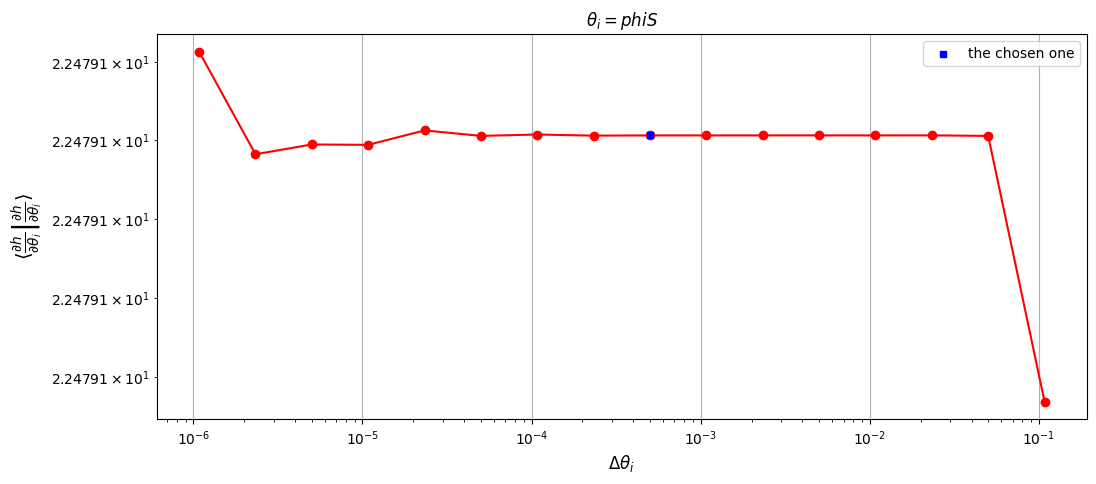

Gamma_ii for dev0p: 991919085.4131331
Gamma_ii for dev0p: 991919085.2123469
Gamma_ii for dev0p: 991919085.34367
Gamma_ii for dev0p: 991919082.8378156
Gamma_ii for dev0p: 991919083.1327038
Gamma_ii for dev0p: 991919086.5411112
Gamma_ii for dev0p: 991919089.0294024
Gamma_ii for dev0p: 991919104.3530117
Gamma_ii for dev0p: 991919118.2459263
Gamma_ii for dev0p: 991919185.8747522
Gamma_ii for dev0p: 991919254.0323286
Gamma_ii for dev0p: 991918709.0921633
Gamma_ii for dev0p: 991918731.3113563
Gamma_ii for dev0p: 991923331.5098201
Gamma_ii for dev0p: 991920433.1435084
Gamma_ii for dev0p: 991887100.5173429
[np.float64(2.0242198778272276e-10), np.float64(1.3239295530930635e-10), np.float64(2.5262689382290676e-09), np.float64(2.9729051873841764e-10), np.float64(3.4361748815698634e-09), np.float64(2.5085626155313106e-09), np.float64(1.544844663729587e-08), np.float64(1.4006096140361562e-08), np.float64(6.817977398360174e-08), np.float64(6.871282734425421e-08), np.float64(5.493798637794049e-07), n

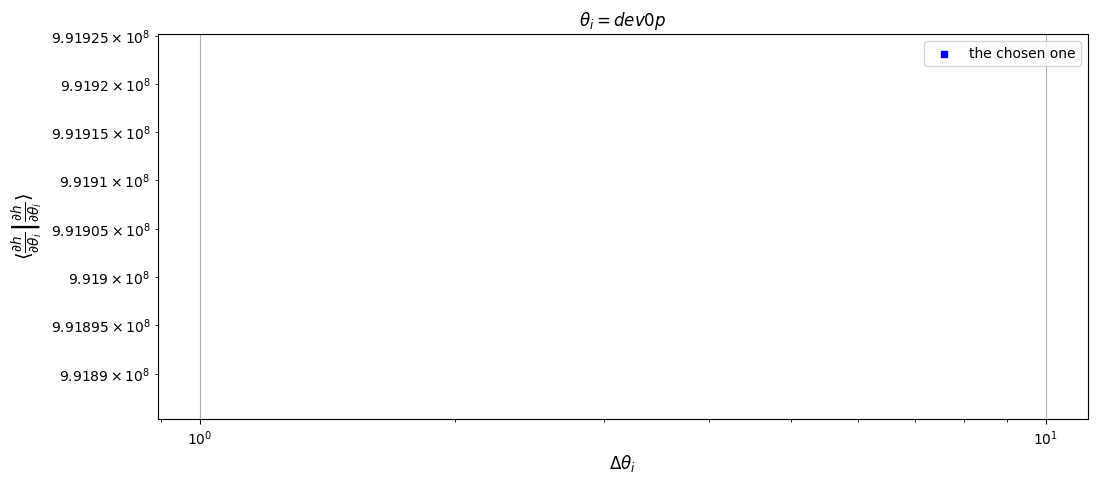

Gamma_ii for dev0e: 281638529.9176754
Gamma_ii for dev0e: 281638554.7632369
Gamma_ii for dev0e: 281638544.92871606
Gamma_ii for dev0e: 281638681.3889757
Gamma_ii for dev0e: 281639175.5987112
Gamma_ii for dev0e: 281637630.9026296
Gamma_ii for dev0e: 281636406.86696136
Gamma_ii for dev0e: 281634412.50297785
Gamma_ii for dev0e: 281641422.5977858
Gamma_ii for dev0e: 281628984.5656784
Gamma_ii for dev0e: 281670595.42390597
Gamma_ii for dev0e: 281592005.79534733
Gamma_ii for dev0e: 281648345.49877703
Gamma_ii for dev0e: 282354082.7838411
Gamma_ii for dev0e: 282382338.1279121
Gamma_ii for dev0e: 280835072.5642624
[np.float64(8.821789873638132e-08), np.float64(3.49189448457495e-08), np.float64(4.845224347145254e-07), np.float64(1.7547620442438016e-06), np.float64(5.484693492940147e-06), np.float64(4.346155675931859e-06), np.float64(7.081393093220941e-06), np.float64(2.4890141312537004e-05), np.float64(4.4164602327899064e-05), np.float64(0.00014772879705433174), np.float64(0.0002790904107403969

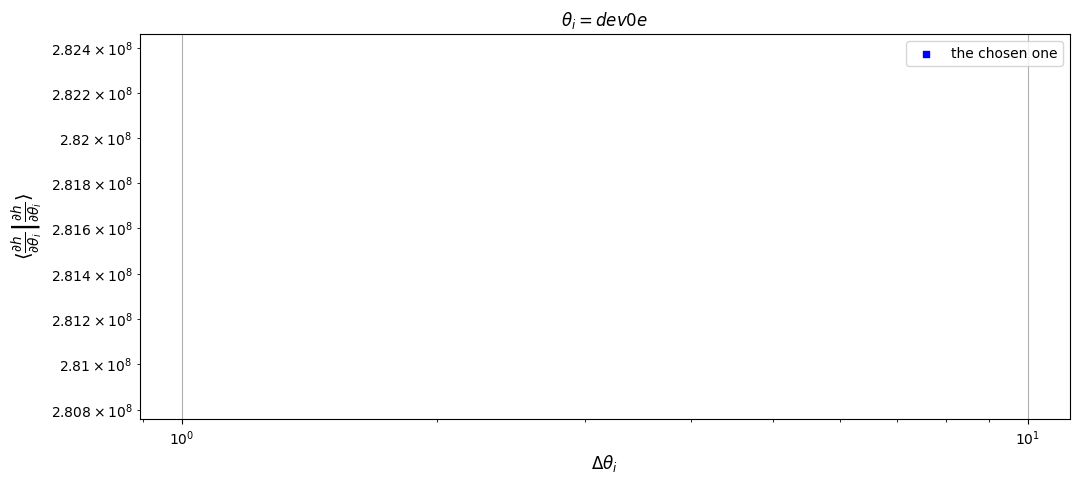

stable deltas: {'m1': 0.21643041615822173, 'm2': 0.1364270047821361, 'a': -8.961514129999993e-06, 'p0': 0.00019568545426353146, 'e0': 2.320600690813243e-06, 'qS': 0.0176591062, 'phiS': 0.0005019440853804657, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': -0.004915481706345251, 'dev0e': -3.5011839011494273e-05}
Time taken to compute stable deltas is 224.8592813014984 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 15.97268295288086 seconds


In [5]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [22]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))


In [23]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8,9,10
0,1.001026e+11,-1.891366e+06,4.079921e+08,3.854309e+09,1.277441e+11,227430.263424,-9.959330e+05,-2.413294e+06,-4.003428e+06,-9.659010e+09,-5.241106e+09
1,-1.891366e+06,3.756511e+01,-8.708272e+03,-7.318079e+04,-2.357401e+06,-3.948243,1.712496e+01,4.158587e+01,6.533650e+01,1.929466e+05,1.026257e+05
2,4.079921e+08,-8.708272e+03,2.632765e+06,1.596019e+07,4.902773e+08,1007.857707,-3.778999e+03,-9.434541e+03,-9.443039e+03,-4.515668e+07,-2.326592e+07
3,3.854309e+09,-7.318079e+04,1.596019e+07,1.484816e+08,4.907693e+09,8724.415383,-3.810243e+04,-9.237526e+04,-1.519682e+05,-3.739522e+08,-2.024947e+08
4,1.277441e+11,-2.357401e+06,4.902773e+08,4.907693e+09,1.647482e+11,301496.096121,-1.324124e+06,-3.206153e+06,-5.429297e+06,-1.200558e+10,-6.577271e+09
5,2.274303e+05,-3.948243e+00,1.007858e+03,8.724415e+03,3.014961e+05,38.350775,8.390296e+00,-8.079896e+00,-1.118798e+01,-2.005721e+04,-1.110207e+04
6,-9.959330e+05,1.712496e+01,-3.778999e+03,-3.810243e+04,-1.324124e+06,8.390296,2.247909e+01,3.403724e+01,5.408530e+01,8.689563e+04,4.846936e+04
7,-2.413294e+06,4.158587e+01,-9.434541e+03,-9.237526e+04,-3.206153e+06,-8.079896,3.403724e+01,8.363989e+01,1.299650e+02,2.111111e+05,1.175635e+05
8,-4.003428e+06,6.533650e+01,-9.443039e+03,-1.519682e+05,-5.429297e+06,-11.187979,5.408530e+01,1.299650e+02,2.680945e+02,3.293824e+05,1.878305e+05
9,-9.659010e+09,1.929466e+05,-4.515668e+07,-3.739522e+08,-1.200558e+10,-20057.207830,8.689563e+04,2.111111e+05,3.293824e+05,9.919191e+08,5.260829e+08


In [24]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):

    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                ax.axis("off")
                continue
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D - 1 and j == 0:
                    # ellipse handles (match levels dynamically)
                    level_labels = {f"{int(p*100)}%" for p in levels}
                    for item in ax.get_lines():
                        if item.get_label() in level_labels:
                            legend_handles.append(item)
                
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


In [25]:
m1_true = 1e6
m2_true = 1e4
a_true = -0.9 
e0_true = 5.00000000e-01
xI0_true = 1.0
dist_true = 5
qS_true = 1.04719755e+00
phiS_true = 7.85398163e-01
qK_true = 6.28318531e-01
phiK_true = 6.28318531e-01
Phi_phi0_true = 0.1
Phi_theta0_true = 0.2
Phi_r0_true = 0.3
p0_true= 42.0
dev_0_p_true=0.0
dev_0_e_true=0.0

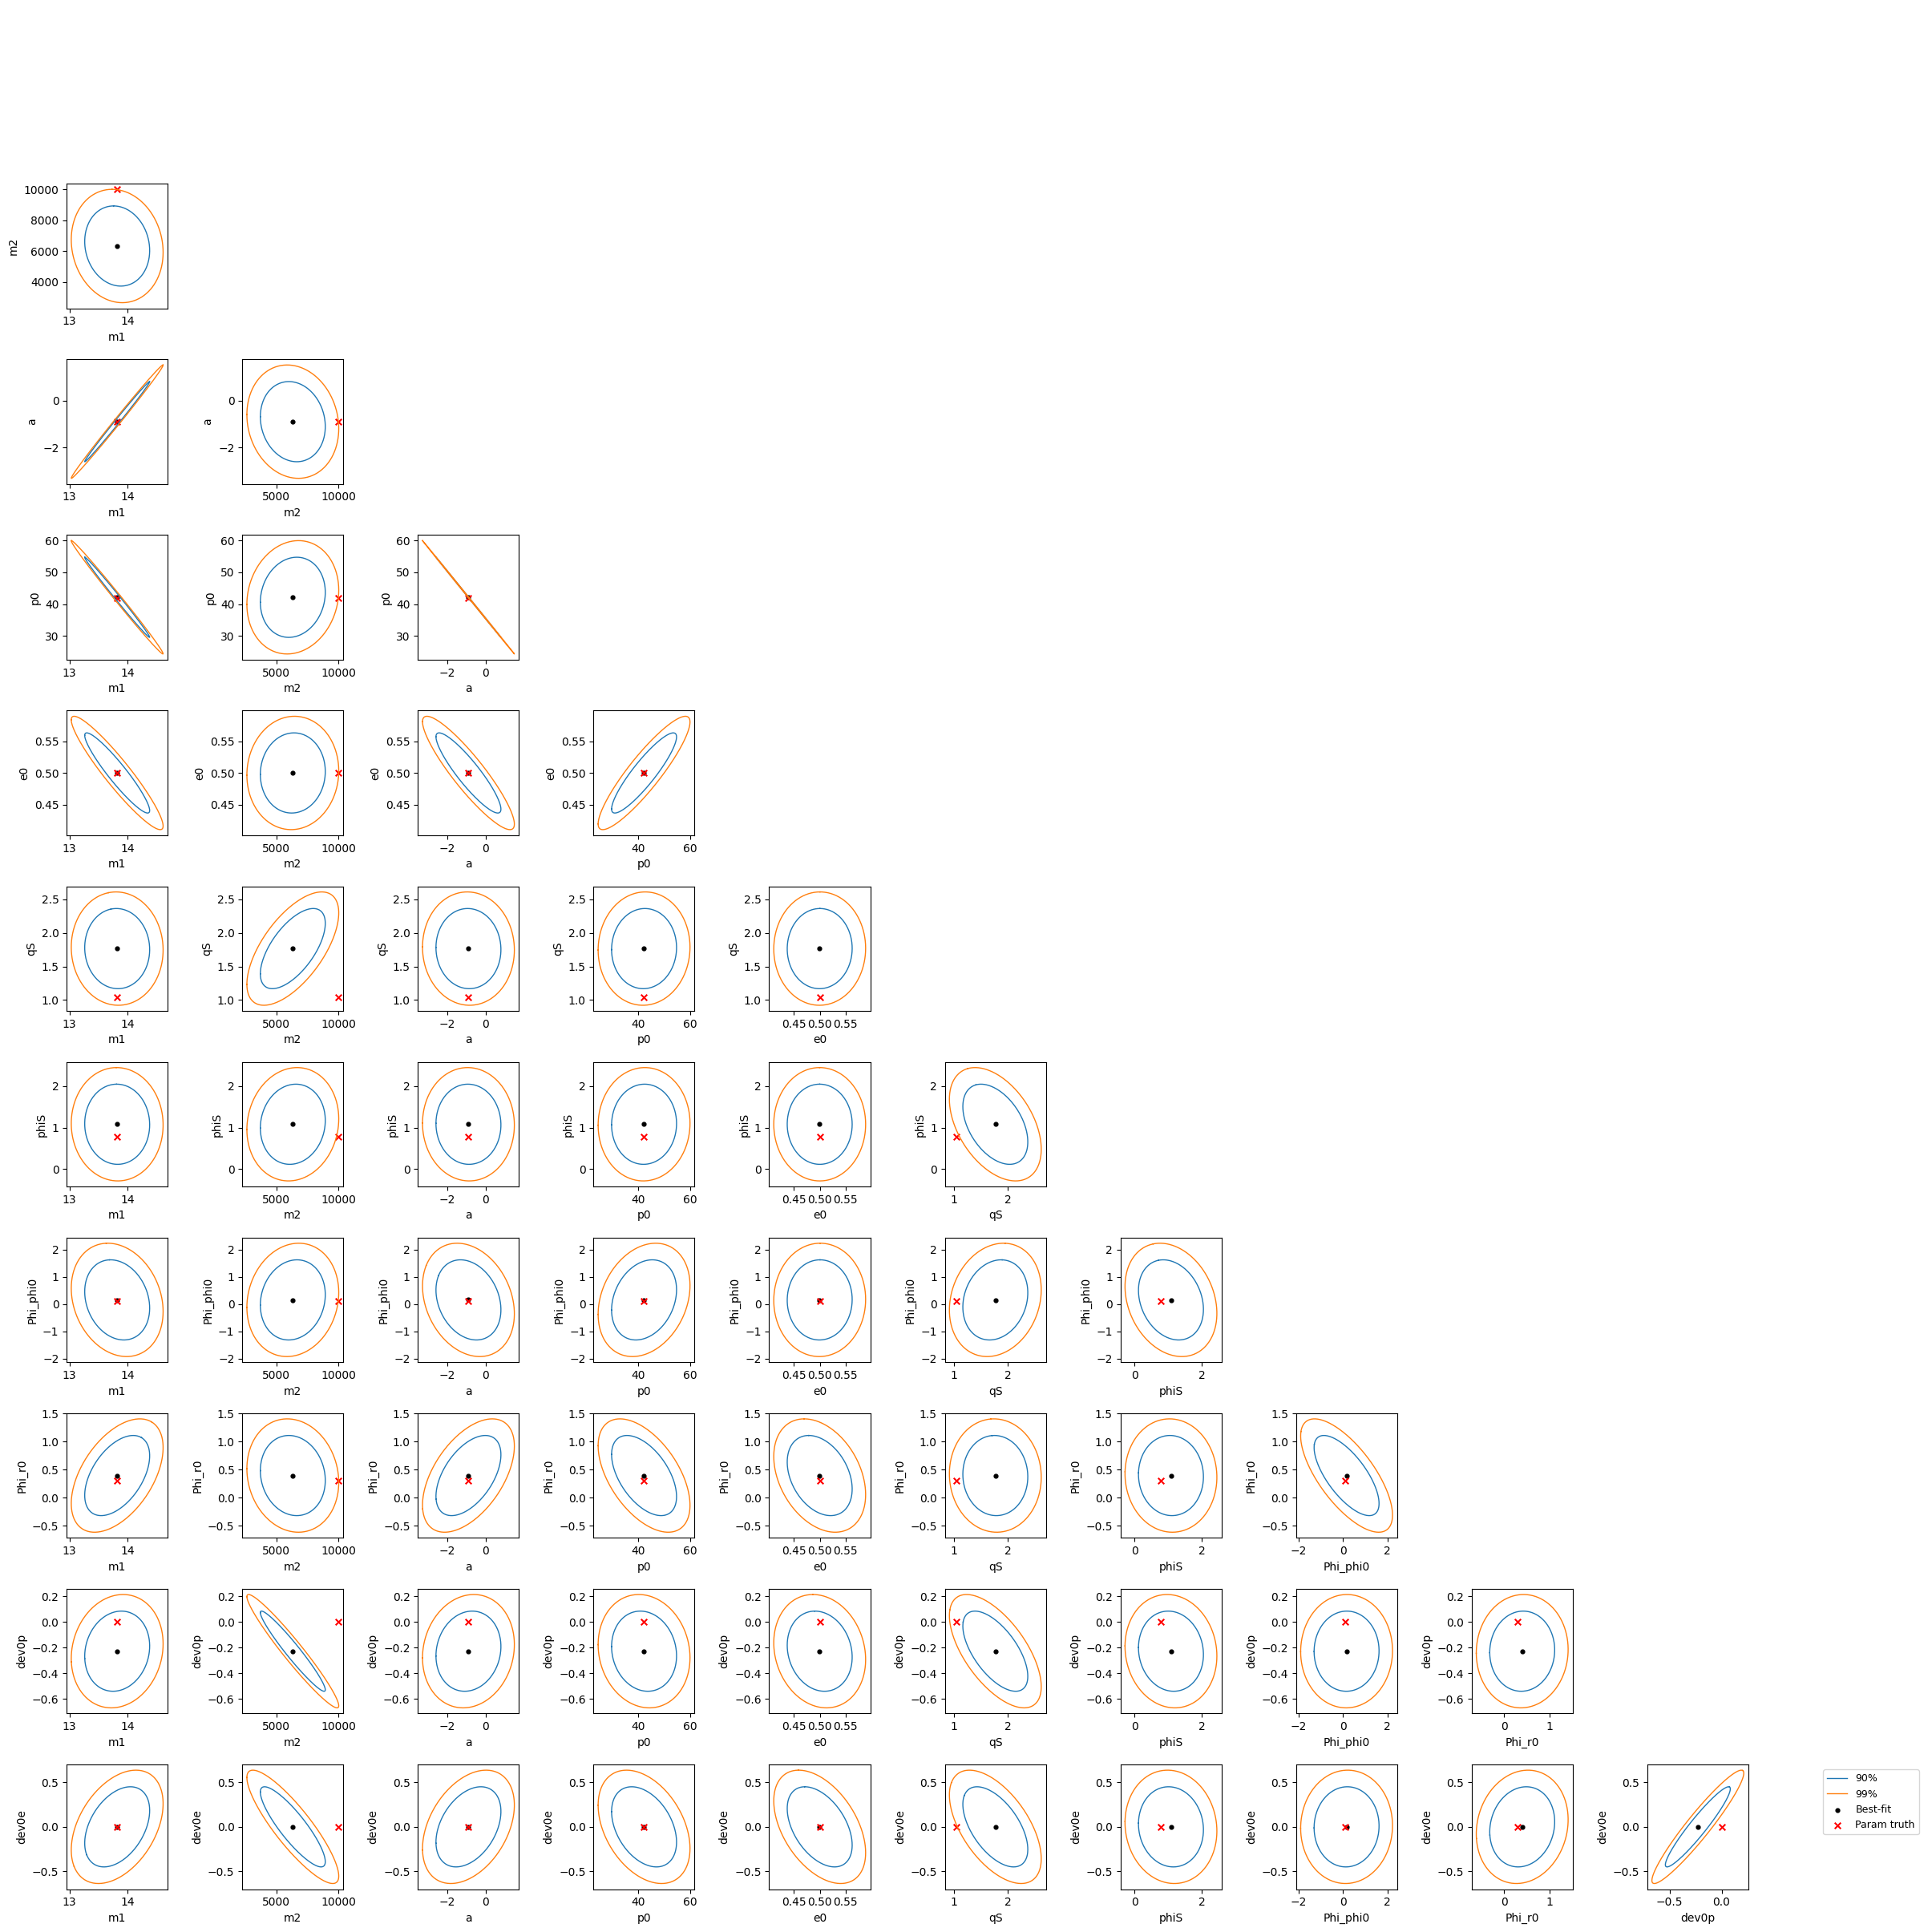

In [26]:
labels = param_names
params_truth_in = [np.log(m1_true), m2_true, a_true, p0_true, e0_true, qS_true, phiS_true, Phi_phi0_true, Phi_r0_true, dev_0_p_true, dev_0_e_true]
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.90, 0.99])


In [37]:
# True waveform with 1PA order
m1_true = 1e6
m2_true = 1e4
a_true = -0.9 
e0_true = 5.00000000e-01
xI0_true = 1.0
dist_true = 5
qS_true = 1.04719755e+00
phiS_true = 7.85398163e-01
qK_true = 6.28318531e-01
phiK_true =  5.23598776e-01
Phi_phi0_true = 0.1
Phi_theta0_true = 0.2
Phi_r0_true = 0.3
p0_true= 42.0
dev_0_p_true=0.0
dev_0_e_true=0.0

evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
chi2 = 9.50000000e-01

add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])




In [38]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [39]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)

# waveform analysis and p0 evolution 

In [40]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  42.12517286673345
separatrix p:  10.078971965107378


# P evolution is done considering true waveform (1PA)

[0.95, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


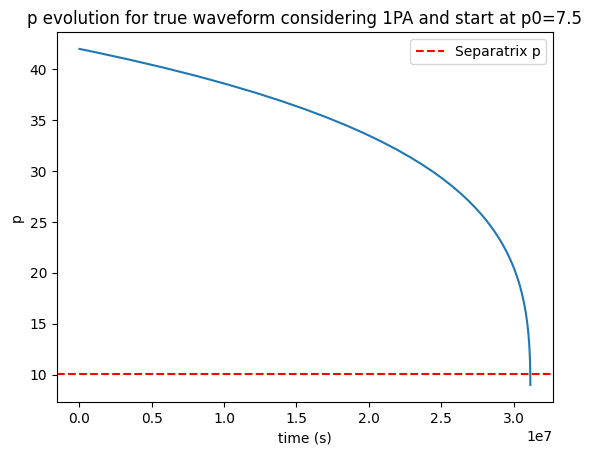

In [41]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.5')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

# Waveform Visualization

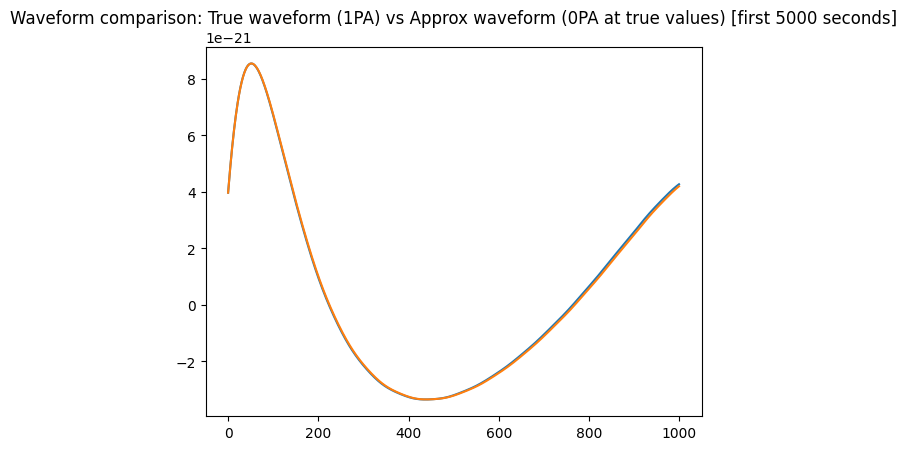

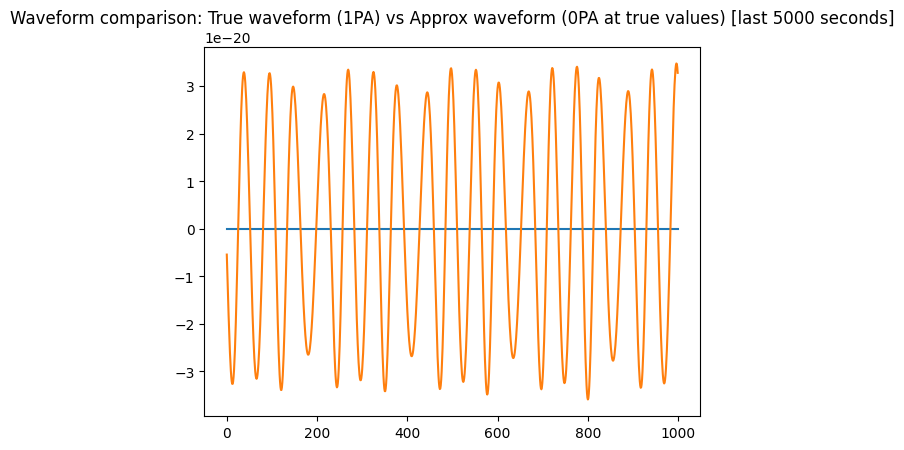

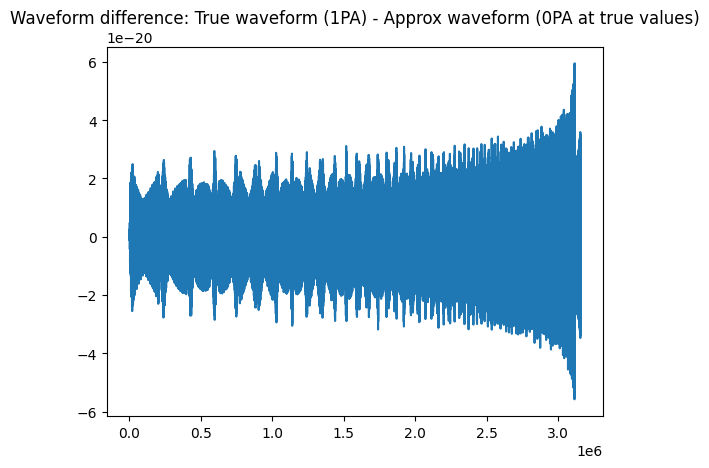

In [42]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

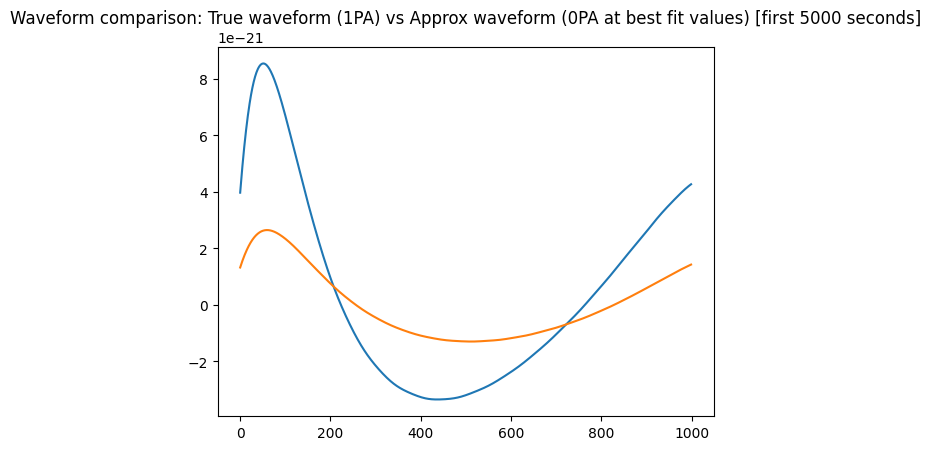

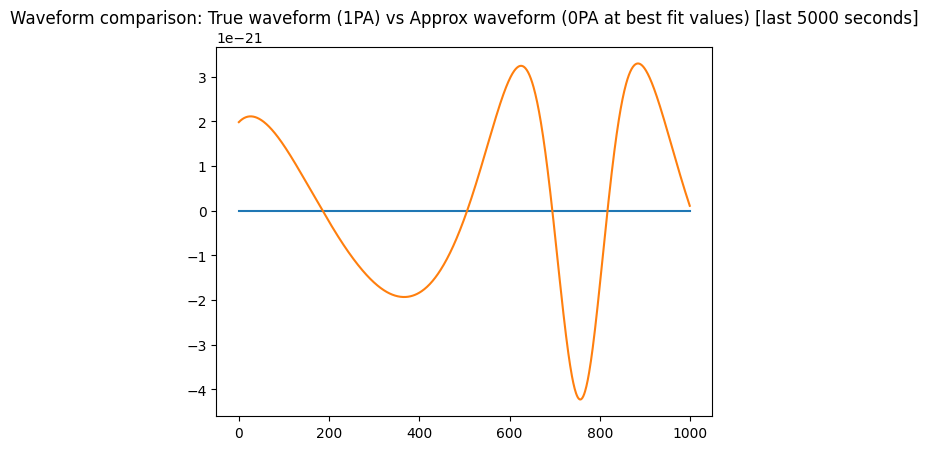

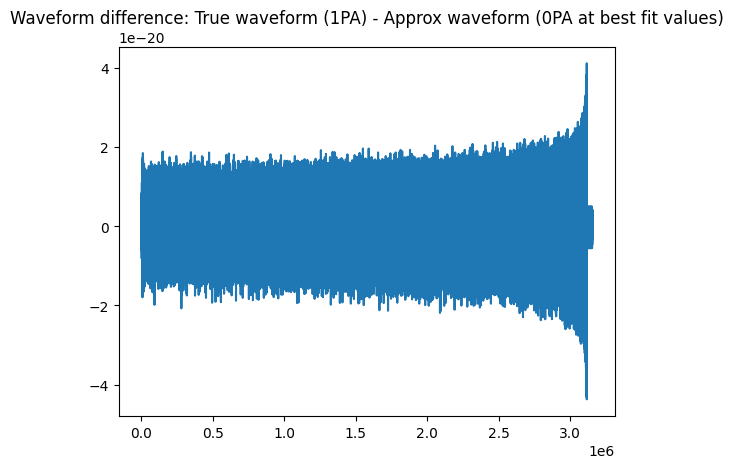

In [43]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

# Overlap and mismatch

In [44]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.005658946534629341
mismatch between best fit point and true waveform: 0.9943410534653706
overlap between approximate waveform and true waveform (both at true points) -0.007483444519670598
mismatch between approximate waveform and true waveform (both at true points): 1.0074834445196705


# table true vs bias

In [35]:
best_fit


[13.8200811,
 6332.38062,
 -0.896151413,
 42.1591531,
 0.499958263,
 1.76591062,
 1.08140575,
 0.15504525,
 0.395573277,
 -0.22815645,
 -0.00162510561]

In [36]:
import pandas as pd
best_fit_ = best_fit.copy()
best_fit_[0] = np.exp(best_fit[0])
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true,dev_0_p_true,dev_0_e_true]
df = pd.DataFrame({'Best Fit': best_fit_, 'True Param': truue_param}, index=param_names)
print(df)

              Best Fit      True Param
m1        1.004581e+06  1000000.000000
m2        6.332381e+03    10000.000000
a        -8.961514e-01       -0.900000
p0        4.215915e+01       42.000000
e0        4.999583e-01        0.500000
qS        1.765911e+00        1.047198
phiS      1.081406e+00        0.785398
Phi_phi0  1.550452e-01        0.100000
Phi_r0    3.955733e-01        0.300000
dev0p    -2.281565e-01        0.000000
dev0e    -1.625106e-03        0.000000


In [21]:
# #Orthoganal check between derivative and exact fisher matrices
# PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
#                 noise_PSD=get_sensitivity,
#                 noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
#                 channels=["A","E"])
# inner_val = []
# for i in range(fisher_derivs.shape[0]):
#     temp_deriv = inner_product(fisher_derivs[i],waveform_true-sef.waveform, PSD=PSD, dt=dt,use_gpu=use_gpu)
#     inner_val.append(temp_deriv)


: 

: 

: 